# Temporal Logistic Regression Baseline for TabReD Homesite Insurance


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports and global settings

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.spatial.distance import cosine
from scipy.stats import wasserstein_distance

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

## 2. Load data from Drive

In [ ]:
PATH_CANDIDATES = [
    "/content/drive/MyDrive/Thesis 6/train.csv",
]

DATA_PATH = None
for path in PATH_CANDIDATES:
    if os.path.exists(path):
        DATA_PATH = path
        break

df = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Loaded from: /content/drive/MyDrive/Thesis 6/train.csv
Shape: (260753, 299)


,QuoteNumber,Original_Quote_Date,QuoteConversion_Flag,Field6,Field7,Field8,Field9,Field10,Field11,Field12,CoverageField1A,CoverageField1B,CoverageField2A,CoverageField2B,CoverageField3A,CoverageField3B,CoverageField4A,CoverageField4B,CoverageField5A,CoverageField5B,CoverageField6A,CoverageField6B,CoverageField8,CoverageField9,CoverageField11A,CoverageField11B,SalesField1A,SalesField1B,SalesField2A,SalesField2B,SalesField3,SalesField4,SalesField5,SalesField6,SalesField7,SalesField8,SalesField9,SalesField10,SalesField11,SalesField12,SalesField13,SalesField14,SalesField15,PersonalField1,PersonalField2,PersonalField4A,PersonalField4B,PersonalField5,PersonalField6,PersonalField7,PersonalField8,PersonalField9,PersonalField10A,PersonalField10B,PersonalField11,PersonalField12,PersonalField13,PersonalField14,PersonalField15,PersonalField16,PersonalField17,PersonalField18,PersonalField19,PersonalField22,PersonalField23,PersonalField24,PersonalField25,PersonalField26,PersonalField27,PersonalField28,PersonalField29,PersonalField30,PersonalField31,PersonalField32,PersonalField33,PersonalField34,PersonalField35,PersonalField36,PersonalField37,PersonalField38,PersonalField39,PersonalField40,PersonalField41,PersonalField42,PersonalField43,PersonalField44,PersonalField45,PersonalField46,PersonalField47,PersonalField48,PersonalField49,PersonalField50,PersonalField51,PersonalField52,PersonalField53,PersonalField54,PersonalField55,PersonalField56,PersonalField57,PersonalField58,PersonalField59,PersonalField60,PersonalField61,PersonalField62,PersonalField63,PersonalField64,PersonalField65,PersonalField66,PersonalField67,PersonalField68,PersonalField69,PersonalField70,PersonalField71,PersonalField72,PersonalField73,PersonalField74,PersonalField75,PersonalField76,PersonalField77,PersonalField78,PersonalField79,PersonalField80,PersonalField81,PersonalField82,PersonalField83,PersonalField84,PropertyField1A,PropertyField1B,PropertyField2A,PropertyField2B,PropertyField3,PropertyField4,PropertyField5,PropertyField6,PropertyField7,PropertyField8,PropertyField9,PropertyField10,PropertyField11A,PropertyField11B,PropertyField12,PropertyField13,PropertyField14,PropertyField15,PropertyField16A,PropertyField16B,PropertyField17,PropertyField18,PropertyField19,PropertyField20,PropertyField21A,PropertyField21B,PropertyField22,PropertyField23,PropertyField24A,PropertyField24B,PropertyField25,PropertyField26A,PropertyField26B,PropertyField27,PropertyField28,PropertyField29,PropertyField30,PropertyField31,PropertyField32,PropertyField33,PropertyField34,PropertyField35,PropertyField36,PropertyField37,PropertyField38,PropertyField39A,PropertyField39B,GeographicField1A,GeographicField1B,GeographicField2A,GeographicField2B,GeographicField3A,GeographicField3B,GeographicField4A,GeographicField4B,GeographicField5A,GeographicField5B,GeographicField6A,GeographicField6B,GeographicField7A,GeographicField7B,GeographicField8A,GeographicField8B,GeographicField9A,GeographicField9B,GeographicField10A,GeographicField10B,GeographicField11A,GeographicField11B,GeographicField12A,GeographicField12B,GeographicField13A,GeographicField13B,GeographicField14A,GeographicField14B,GeographicField15A,GeographicField15B,GeographicField16A,GeographicField16B,GeographicField17A,GeographicField17B,GeographicField18A,GeographicField18B,GeographicField19A,GeographicField19B,GeographicField20A,GeographicField20B,GeographicField21A,GeographicField21B,GeographicField22A,GeographicField22B,GeographicField23A,GeographicField23B,GeographicField24A,GeographicField24B,GeographicField25A,GeographicField25B,GeographicField26A,GeographicField26B,GeographicField27A,GeographicField27B,GeographicField28A,GeographicField28B,GeographicField29A,GeographicField29B,GeographicField30A,GeographicField30B,GeographicField31A,GeographicField31B,GeographicField32A,GeographicField32B,GeographicField33A,GeographicField33B,GeographicField34A,GeographicField34B,GeographicField35A,GeographicField35B,GeographicField36A,GeographicFie

## 3. Basic schema check

Voor Homesite Insurance gebruiken we:
- `Original_Quote_Date` als datumkolom
- `QuoteConversion_Flag` als target
- `QuoteNumber` als identifier

In [ ]:
DATE_COL = "Original_Quote_Date"
TARGET_COL = "QuoteConversion_Flag"
ID_COL = "QuoteNumber"

required_cols = [DATE_COL, TARGET_COL, ID_COL]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Verplichte kolommen ontbreken: {missing_required}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()
df = df.sort_values(DATE_COL).reset_index(drop=True)

print(df[[DATE_COL, TARGET_COL, ID_COL]].dtypes)
print("Target mean:", df[TARGET_COL].mean())

Original_Quote_Date     datetime64[ns]
QuoteConversion_Flag             int64
QuoteNumber                      int64
dtype: object
Target mean: 0.1875107860695754


## 4. Time overview


In [ ]:
start_date = df[DATE_COL].min()
end_date = df[DATE_COL].max()

summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_columns",
        "n_unique_ids",
        "start_date",
        "end_date",
        "time_span_days",
        "time_span_months_approx",
        "positive_rate"
    ],
    "value": [
        len(df),
        df.shape[1],
        df[ID_COL].nunique(),
        start_date,
        end_date,
        (end_date - start_date).days + 1,
        round(((end_date.year - start_date.year) * 12 + (end_date.month - start_date.month) + 1), 2),
        round(df[TARGET_COL].mean(), 6)
    ]
})

display(summary)

,metric,value
0,n_rows,260753
1,n_columns,299
2,n_unique_ids,260753
3,start_date,2013-01-01 00:00:00
4,end_date,2015-05-18 00:00:00
5,time_span_days,868
6,time_span_months_approx,29
7,positive_rate,0.187511


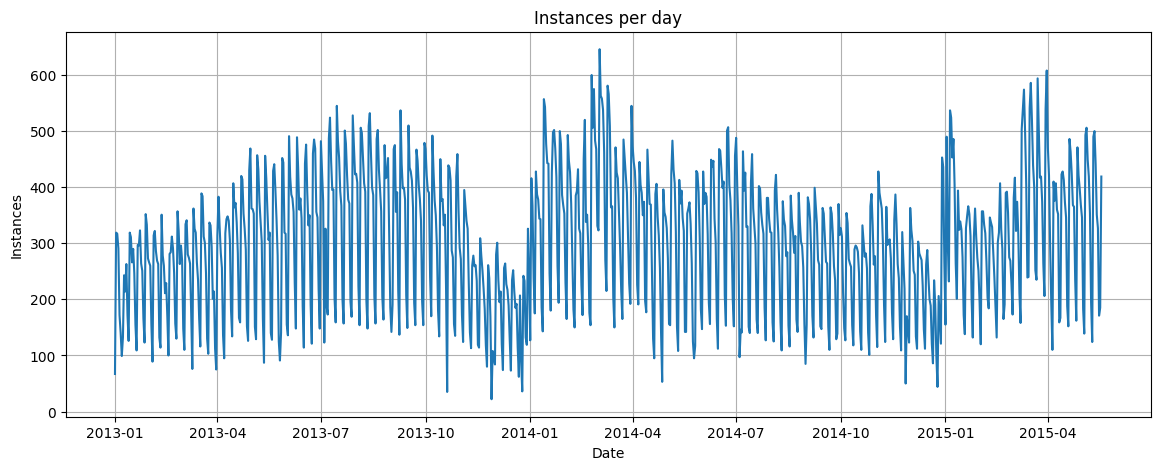

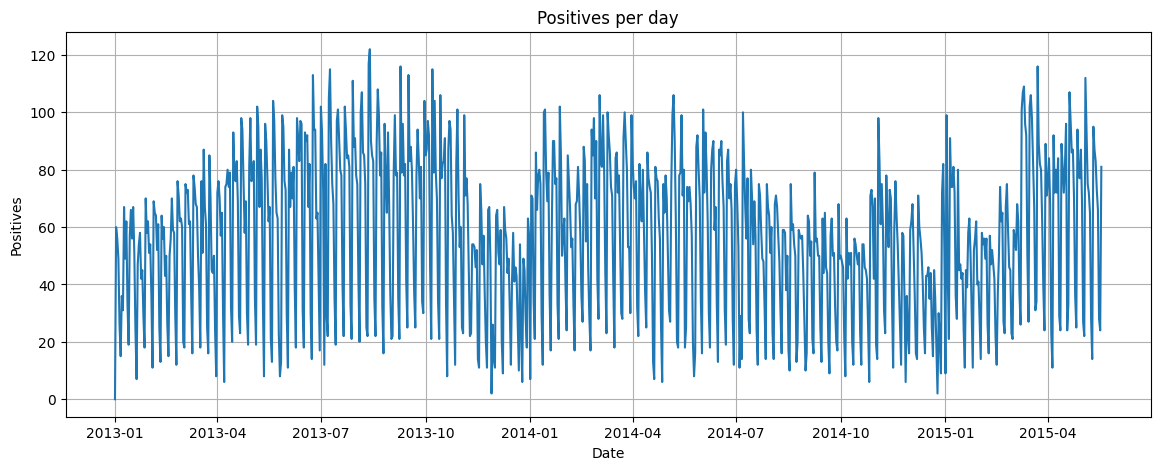

In [ ]:
daily = (
    df.groupby(DATE_COL)
      .agg(instances=(ID_COL, "count"), positives=(TARGET_COL, "sum"))
      .reset_index()
      .sort_values(DATE_COL)
)
daily["positive_rate"] = daily["positives"] / daily["instances"]

plt.figure()
plt.plot(daily[DATE_COL], daily["instances"])
plt.title("Instances per day")
plt.xlabel("Date")
plt.ylabel("Instances")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(daily[DATE_COL], daily["positives"])
plt.title("Positives per day")
plt.xlabel("Date")
plt.ylabel("Positives")
plt.grid(True)
plt.show()

## 5. Choose monthly time steps

We kiezen **maand** als tijdseenheid.
Elke rij krijgt een `month_step` op basis van `Original_Quote_Date`.

,month_step,month_str,instances,positives,positive_rate
0,0,2013-01,7195,1365,0.189715
1,1,2013-02,6744,1370,0.203144
2,2,2013-03,7493,1596,0.212999
3,3,2013-04,8833,1884,0.213291
4,4,2013-05,9413,1980,0.210347
5,5,2013-06,9798,1951,0.199122
6,6,2013-07,11241,2219,0.197402
7,7,2013-08,11272,2211,0.196150
8,8,2013-09,10245,2013,0.196486
9,9,2013-10,10148,2165,0.213343


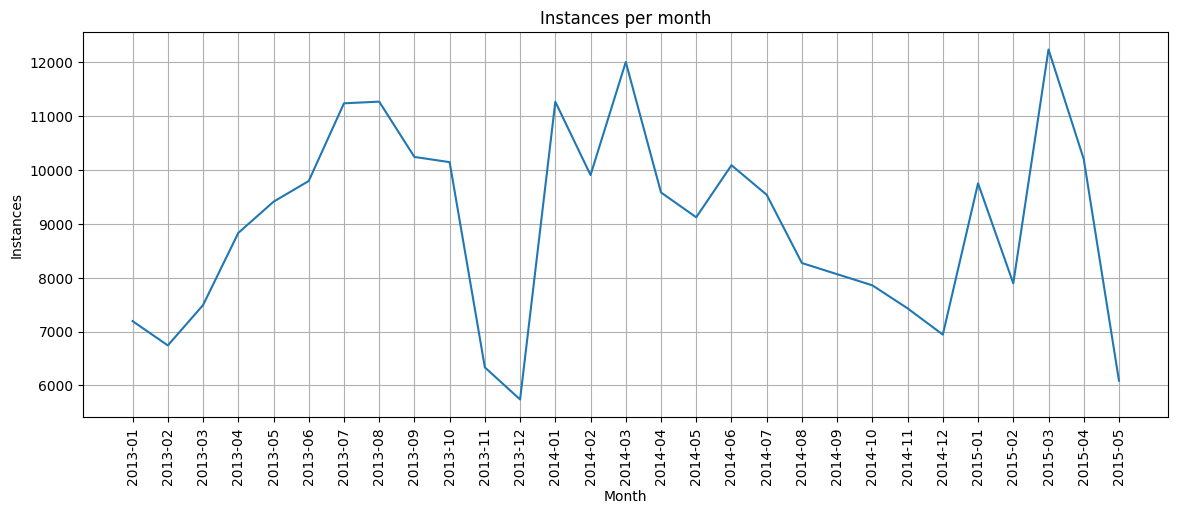

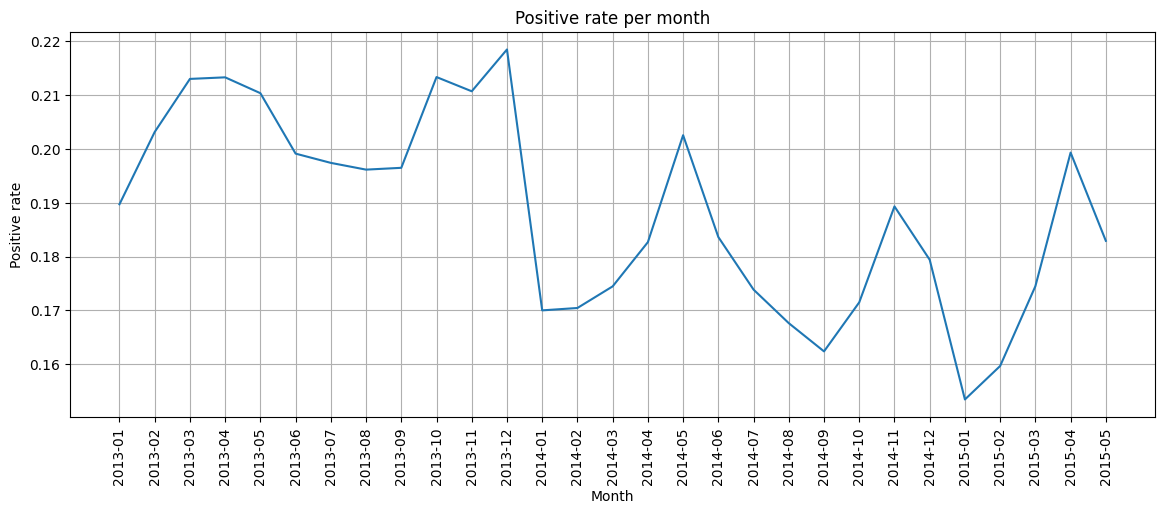

Aantal maand-timesteps: 29


In [ ]:
df["year_month"] = df[DATE_COL].dt.to_period("M")
month_order = np.sort(df["year_month"].astype(str).unique())
month_to_step = {m: i for i, m in enumerate(month_order)}
step_to_month = {i: m for m, i in month_to_step.items()}

df["month_str"] = df["year_month"].astype(str)
df["month_step"] = df["month_str"].map(month_to_step).astype(int)

monthly = (
    df.groupby(["month_step", "month_str"])
      .agg(
          instances=(ID_COL, "count"),
          positives=(TARGET_COL, "sum"),
          positive_rate=(TARGET_COL, "mean")
      )
      .reset_index()
      .sort_values("month_step")
)

display(monthly)

plt.figure()
plt.plot(monthly["month_str"], monthly["instances"])
plt.title("Instances per month")
plt.xlabel("Month")
plt.ylabel("Instances")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

plt.figure()
plt.plot(monthly["month_str"], monthly["positive_rate"])
plt.title("Positive rate per month")
plt.xlabel("Month")
plt.ylabel("Positive rate")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

print("Aantal maand-timesteps:", monthly.shape[0])

## 6. Temporal experiment configuration

In [ ]:
WINDOW_LENGTH_MONTHS = 8
RETRAIN_STEP_MONTHS = 2
PAIR_JUMP_MONTHS = 2
EVAL_HORIZON_MONTHS = 8
VALID_FRAC = 0.20
TOP_K = 30


print({
    "WINDOW_LENGTH_MONTHS": WINDOW_LENGTH_MONTHS,
    "RETRAIN_STEP_MONTHS": RETRAIN_STEP_MONTHS,
    "PAIR_JUMP_MONTHS": PAIR_JUMP_MONTHS,
    "EVAL_HORIZON_MONTHS": EVAL_HORIZON_MONTHS,
    "VALID_FRAC": VALID_FRAC,
    "TOP_K": TOP_K,
})

{'WINDOW_LENGTH_MONTHS': 8, 'RETRAIN_STEP_MONTHS': 2, 'PAIR_JUMP_MONTHS': 2, 'EVAL_HORIZON_MONTHS': 8, 'VALID_FRAC': 0.2, 'TOP_K': 30}


## 7. Feature selection and leakage-safe preprocessing

We verwijderen:
- identifier
- target
- ruwe datumkolom
- afgeleide timestepkolommen

Preprocessing:
- numeriek: median imputation + scaling
- categorisch: most-frequent imputation + one-hot encoding


In [ ]:
DROP_COLS = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    "year_month",
    "month_str",
    "month_step",
]

feature_cols = [c for c in df.columns if c not in DROP_COLS]

X_all = df[feature_cols].copy()
numeric_cols = X_all.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print("Aantal features:", len(feature_cols))
print("Numeriek:", len(numeric_cols))
print("Categorisch:", len(categorical_cols))
print()
print("Voorbeeld numeriek:", numeric_cols[:20])
print("Voorbeeld categorisch:", categorical_cols[:20])

Aantal features: 296
Numeriek: 269
Categorisch: 27

Voorbeeld numeriek: ['Field7', 'Field8', 'Field9', 'Field11', 'CoverageField1A', 'CoverageField1B', 'CoverageField2A', 'CoverageField2B', 'CoverageField3A', 'CoverageField3B', 'CoverageField4A', 'CoverageField4B', 'CoverageField5A', 'CoverageField5B', 'CoverageField6A', 'CoverageField6B', 'CoverageField11A', 'CoverageField11B', 'SalesField1A', 'SalesField1B']
Voorbeeld categorisch: ['Field6', 'Field10', 'Field12', 'CoverageField8', 'CoverageField9', 'SalesField7', 'PersonalField7', 'PersonalField16', 'PersonalField17', 'PersonalField18', 'PersonalField19', 'PropertyField3', 'PropertyField4', 'PropertyField5', 'PropertyField7', 'PropertyField14', 'PropertyField28', 'PropertyField30', 'PropertyField31', 'PropertyField32']


In [ ]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

base_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

reference_drift_preprocessor = clone(preprocessor)
reference_drift_preprocessor.fit(df[feature_cols])

print("Reference drift preprocessor fitted on full dataset.")

Reference drift preprocessor fitted on full dataset.


## 8. Helper functions


In [ ]:
def get_window_data(data, end_step, window_length, step_col="month_step"):
    start_step = end_step - window_length + 1
    return data[data[step_col].between(start_step, end_step)].copy()

def get_eval_slice(data, start_step, horizon, step_col="month_step"):
    return data[data[step_col].between(start_step + 1, start_step + horizon)].copy()

def temporal_train_valid_split(window_df, date_col, valid_frac=0.2):
    window_df = window_df.sort_values(date_col).reset_index(drop=True)
    n = len(window_df)
    split_idx = max(1, int(np.floor(n * (1 - valid_frac))))
    split_idx = min(split_idx, n - 1)
    train_df = window_df.iloc[:split_idx].copy()
    valid_df = window_df.iloc[split_idx:].copy()
    return train_df, valid_df

def get_feature_names_from_preprocessor(fitted_preprocessor):
    feature_names = []
    if numeric_cols:
        feature_names.extend(numeric_cols)
    if categorical_cols:
        encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["encoder"]
        feature_names.extend(encoder.get_feature_names_out(categorical_cols).tolist())
    return feature_names

def fit_temporal_logreg(train_df, valid_df, feature_cols, target_col):
    X_train = train_df[feature_cols]
    y_train = train_df[target_col].values
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target_col].values

    prep = clone(preprocessor)
    model = clone(base_model)

    X_train_t = prep.fit_transform(X_train)
    X_valid_t = prep.transform(X_valid)

    model.fit(X_train_t, y_train)

    valid_pred = model.predict_proba(X_valid_t)[:, 1]
    valid_ap = average_precision_score(y_valid, valid_pred)
    valid_acc = accuracy_score(y_valid, (valid_pred >= 0.5).astype(int))

    feature_names = get_feature_names_from_preprocessor(prep)
    coefs = np.asarray(model.coef_).ravel()

    return {
        "preprocessor": prep,
        "model": model,
        "feature_names": feature_names,
        "coefs": coefs,
        "valid_ap": valid_ap,
        "valid_acc": valid_acc,
        "n_train": len(train_df),
        "n_valid": len(valid_df),
    }

def predict_model(bundle, data, feature_cols):
    X = data[feature_cols]
    Xt = bundle["preprocessor"].transform(X)
    return bundle["model"].predict_proba(Xt)[:, 1]

def evaluate_on_slice(bundle, eval_df, feature_cols, target_col):
    y_true = eval_df[target_col].values
    pred = predict_model(bundle, eval_df, feature_cols)
    ap = average_precision_score(y_true, pred)
    acc = accuracy_score(y_true, (pred >= 0.5).astype(int))
    try:
        roc = roc_auc_score(y_true, pred)
    except Exception:
        roc = np.nan
    return {
        "pr_auc": ap,
        "accuracy": acc,
        "roc_auc": roc,
        "pred": pred,
    }

def align_coefficients(bundle_a, bundle_b):
    coef_a = pd.Series(bundle_a["coefs"], index=bundle_a["feature_names"], dtype=float)
    coef_b = pd.Series(bundle_b["coefs"], index=bundle_b["feature_names"], dtype=float)
    all_features = coef_a.index.union(coef_b.index)
    coef_a = coef_a.reindex(all_features, fill_value=0.0)
    coef_b = coef_b.reindex(all_features, fill_value=0.0)
    return coef_a, coef_b

def coefficient_cosine_distance(bundle_a, bundle_b):
    coef_a, coef_b = align_coefficients(bundle_a, bundle_b)
    va = coef_a.values
    vb = coef_b.values
    if np.linalg.norm(va) == 0 or np.linalg.norm(vb) == 0:
        return np.nan
    return float(cosine(va, vb))

def topk_overlap(bundle_a, bundle_b, k=20):
    coef_a, coef_b = align_coefficients(bundle_a, bundle_b)
    top_a = set(coef_a.abs().sort_values(ascending=False).head(k).index)
    top_b = set(coef_b.abs().sort_values(ascending=False).head(k).index)
    if k == 0:
        return np.nan
    return len(top_a & top_b) / k

def mean_abs_coef_shift(bundle_a, bundle_b):
    coef_a, coef_b = align_coefficients(bundle_a, bundle_b)
    return float(np.mean(np.abs(coef_a.values - coef_b.values)))

def compute_covariate_drift(data_a, data_b, feature_cols):
    X_a = reference_drift_preprocessor.transform(data_a[feature_cols])
    X_b = reference_drift_preprocessor.transform(data_b[feature_cols])

    if sparse.issparse(X_a):
        X_a = X_a.toarray()
    if sparse.issparse(X_b):
        X_b = X_b.toarray()

    wasserstein_distances = []
    for i in range(X_a.shape[1]):
        wd = wasserstein_distance(X_a[:, i], X_b[:, i])
        wasserstein_distances.append(wd)

    if len(wasserstein_distances) == 0:
        return np.nan

    return float(np.mean(wasserstein_distances))

def compute_target_drift(data_a, data_b, target_col):
    fraud_rate_a = data_a[target_col].mean()
    fraud_rate_b = data_b[target_col].mean()
    return float(abs(fraud_rate_a - fraud_rate_b))

def get_top_features_table(bundle, top_n=25):
    s = pd.Series(bundle["coefs"], index=bundle["feature_names"])
    out = pd.DataFrame({
        "feature": s.index,
        "coefficient": s.values,
        "abs_coefficient": np.abs(s.values),
    }).sort_values("abs_coefficient", ascending=False).head(top_n)
    return out.reset_index(drop=True)

## 9. Main experiment loop

Voor elk geldig paar:
- train model A op window A
- train model B op window B
- evalueer beide op dezelfde toekomstige eval-slice
- bereken performance drift, coefficient drift en rank stability


In [ ]:
def run_temporal_logreg_experiment(
    data,
    feature_cols,
    date_col,
    target_col,
    window_length_months=5,
    retrain_step_months=1,
    eval_horizon_months=1,
    pair_jump_months=1,
    valid_frac=0.2,
    top_k=20,
):
    results = []
    bundles = {}

    min_end_a = window_length_months - 1
    max_end_a = data["month_step"].max() - retrain_step_months - eval_horizon_months

    valid_end_as = list(range(min_end_a, max_end_a + 1, pair_jump_months))

    print("Aantal geldige pairs:", len(valid_end_as))
    print("window_length_months =", window_length_months)
    print("retrain_step_months =", retrain_step_months)
    print("eval_horizon_months =", eval_horizon_months)
    print("pair_jump_months =", pair_jump_months)

    for pair_idx, end_a in enumerate(valid_end_as, start=1):
        end_b = end_a + retrain_step_months

        window_a = get_window_data(data, end_a, window_length_months, "month_step")
        window_b = get_window_data(data, end_b, window_length_months, "month_step")
        eval_df = get_eval_slice(data, end_b, eval_horizon_months, "month_step")

        if len(window_a) < 50 or len(window_b) < 50 or len(eval_df) < 20:
            continue
        if window_a[target_col].nunique() < 2 or window_b[target_col].nunique() < 2 or eval_df[target_col].nunique() < 2:
            continue

        train_a, valid_a = temporal_train_valid_split(window_a, date_col, valid_frac)
        train_b, valid_b = temporal_train_valid_split(window_b, date_col, valid_frac)

        if train_a[target_col].nunique() < 2 or valid_a[target_col].nunique() < 2:
            continue
        if train_b[target_col].nunique() < 2 or valid_b[target_col].nunique() < 2:
            continue

        bundle_a = fit_temporal_logreg(train_a, valid_a, feature_cols, target_col)
        bundle_b = fit_temporal_logreg(train_b, valid_b, feature_cols, target_col)

        eval_a = evaluate_on_slice(bundle_a, eval_df, feature_cols, target_col)
        eval_b = evaluate_on_slice(bundle_b, eval_df, feature_cols, target_col)

        coef_cos = coefficient_cosine_distance(bundle_a, bundle_b)
        coef_shift = mean_abs_coef_shift(bundle_a, bundle_b)
        topk = topk_overlap(bundle_a, bundle_b, k=top_k)

        covariate_drift = compute_covariate_drift(window_a, window_b, feature_cols)
        target_drift = compute_target_drift(window_a, window_b, target_col)

        row = {
            "pair_idx": pair_idx,
            "end_a_step": end_a,
            "end_b_step": end_b,
            "window_a_start_month": step_to_month[end_a - window_length_months + 1],
            "window_a_end_month": step_to_month[end_a],
            "window_b_start_month": step_to_month[end_b - window_length_months + 1],
            "window_b_end_month": step_to_month[end_b],
            "eval_start_month": step_to_month[end_b + 1],
            "eval_end_month": step_to_month[end_b + eval_horizon_months],
            "n_window_a": len(window_a),
            "n_window_b": len(window_b),
            "n_eval": len(eval_df),
            "train_a_n": bundle_a["n_train"],
            "valid_a_n": bundle_a["n_valid"],
            "train_b_n": bundle_b["n_train"],
            "valid_b_n": bundle_b["n_valid"],
            "window_a_positive_rate": window_a[target_col].mean(),
            "window_b_positive_rate": window_b[target_col].mean(),
            "eval_positive_rate": eval_df[target_col].mean(),
            "valid_pr_auc_a": bundle_a["valid_ap"],
            "valid_pr_auc_b": bundle_b["valid_ap"],
            "eval_pr_auc_a": eval_a["pr_auc"],
            "eval_pr_auc_b": eval_b["pr_auc"],
            "eval_accuracy_a": eval_a["accuracy"],
            "eval_accuracy_b": eval_b["accuracy"],
            "eval_roc_auc_a": eval_a["roc_auc"],
            "eval_roc_auc_b": eval_b["roc_auc"],
            "delta_pr_auc_b_minus_a": eval_b["pr_auc"] - eval_a["pr_auc"],
            "delta_accuracy_b_minus_a": eval_b["accuracy"] - eval_a["accuracy"],
            "target_drift": target_drift,
            "covariate_drift": covariate_drift,
            "coef_cosine_distance": coef_cos,
            "coef_mean_abs_shift": coef_shift,
            f"top_{top_k}_overlap": topk,
        }

        results.append(row)
        bundles[(pair_idx, "A")] = bundle_a
        bundles[(pair_idx, "B")] = bundle_b

        print(
            f"Pair {pair_idx}: "
            f"A [{row['window_a_start_month']} -> {row['window_a_end_month']}], "
            f"B [{row['window_b_start_month']} -> {row['window_b_end_month']}], "
            f"Eval [{row['eval_start_month']} -> {row['eval_end_month']}] | "
            f"PR-AUC A={row['eval_pr_auc_a']:.4f}, B={row['eval_pr_auc_b']:.4f} | "
            f"Target drift={row['target_drift']:.4f}, Covariate drift={row['covariate_drift']:.4f}"
        )

    results_df = pd.DataFrame(results)
    return results_df, bundles

## 10. Run the experiment


In [ ]:
results_df, model_bundles = run_temporal_logreg_experiment(
    data=df,
    feature_cols=feature_cols,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    window_length_months=WINDOW_LENGTH_MONTHS,
    retrain_step_months=RETRAIN_STEP_MONTHS,
    eval_horizon_months=EVAL_HORIZON_MONTHS,
    pair_jump_months=PAIR_JUMP_MONTHS,
    valid_frac=VALID_FRAC,
    top_k=TOP_K,
)

print()
print("Aantal geëvalueerde pairs:", len(results_df))
display(results_df)

Aantal geldige pairs: 6
window_length_months = 8
retrain_step_months = 2
eval_horizon_months = 8
pair_jump_months = 2
Pair 1: A [2013-01 -> 2013-08], B [2013-03 -> 2013-10], Eval [2013-11 -> 2014-06] | PR-AUC A=0.8423, B=0.8510 | Target drift=0.0017, Covariate drift=0.0135
Pair 2: A [2013-03 -> 2013-10], B [2013-05 -> 2013-12], Eval [2014-01 -> 2014-08] | PR-AUC A=0.8469, B=0.8478 | Target drift=0.0003, Covariate drift=0.0063
Pair 3: A [2013-05 -> 2013-12], B [2013-07 -> 2014-02], Eval [2014-03 -> 2014-10] | PR-AUC A=0.8462, B=0.8443 | Target drift=0.0095, Covariate drift=0.0078
Pair 4: A [2013-07 -> 2014-02], B [2013-09 -> 2014-04], Eval [2014-05 -> 2014-12] | PR-AUC A=0.8321, B=0.8319 | Target drift=0.0054, Covariate drift=0.0085
Pair 5: A [2013-09 -> 2014-04], B [2013-11 -> 2014-06], Eval [2014-07 -> 2015-02] | PR-AUC A=0.8026, B=0.8123 | Target drift=0.0034, Covariate drift=0.0177
Pair 6: A [2013-11 -> 2014-06], B [2014-01 -> 2014-08], Eval [2014-09 -> 2015-04] | PR-AUC A=0.8067, B

,pair_idx,end_a_step,end_b_step,window_a_start_month,window_a_end_month,window_b_start_month,window_b_end_month,eval_start_month,eval_end_month,n_window_a,n_window_b,n_eval,train_a_n,valid_a_n,train_b_n,valid_b_n,window_a_positive_rate,window_b_positive_rate,eval_positive_rate,valid_pr_auc_a,valid_pr_auc_b,eval_pr_auc_a,eval_pr_auc_b,eval_accuracy_a,eval_accuracy_b,eval_roc_auc_a,eval_roc_auc_b,delta_pr_auc_b_minus_a,delta_accuracy_b_minus_a,target_drift,covariate_drift,coef_cosine_distance,coef_mean_abs_shift,top_30_overlap
0,1,7,9,2013-01,2013-08,2013-03,2013-10,2013-11,2014-06,71989,78443,74063,57591,14398,62754,15689,0.202475,0.204212,0.185531,0.870856,0.857257,0.842321,0.850978,0.876011,0.881547,0.942846,0.945864,0.008657,0.005536,0.001737,0.013504,0.065382,0.070795,0.766667
1,2,9,11,2013-03,2013-10,2013-05,2013-12,2014-01,2014-08,78443,74193,79803,62754,15689,59354,14839,0.204212,0.203901,0.177913,0.857257,0.854282,0.846851,0.847795,0.882598,0.870719,0.946384,0.945870,0.000944,-0.011879,0.000311,0.006324,0.052070,0.064112,0.733333
2,3,11,13,2013-05,2013-12,2013-07,2014-02,2014-03,2014-10,74193,76161,74551,59354,14839,60928,15233,0.203901,0.194351,0.177744,0.854282,0.844691,0.846178,0.844287,0.862832,0.860579,0.943259,0.942256,-0.001891,-0.002253,0.009549,0.007850,0.043720,0.056062,0.766667
3,4,13,15,2013-07,2014-02,2013-09,2014-04,2014-05,2014-12,76161,75241,67335,60928,15233,60192,15049,0.194351,0.188966,0.179075,0.844691,0.861662,0.832085,0.831882,0.847939,0.844613,0.935734,0.935908,-0.000203,-0.003327,0.005385,0.008521,0.039717,0.052225,0.833333
4,5,15,17,2013-09,2014-04,2013-11,2014-06,2014-07,2015-02,75241,74063,65772,60192,15049,59250,14813,0.188966,0.185531,0.168993,0.861662,0.866980,0.802632,0.812283,0.831554,0.851396,0.923765,0.929345,0.009650,0.019841,0.003435,0.017744,0.047565,0.057548,0.800000
5,6,17,19,2013-11,2014-06,2014-01,2014-08,2014-09,2015-04,74063,79803,70402,59250,14813,63842,15961,0.185531,0.177913,0.173844,0.866980,0.844238,0.806730,0.808152,0.843186,0.836496,0.923539,0.922981,0.001423,-0.006690,0.007618,0.011321,0.066621,0.070639,0.766667


## 11. Results summary

In [ ]:
if len(results_df) == 0:
    print("Geen geldige pairs gevonden. Verlaag eventueel constraints of controleer de maandverdeling.")
else:
    summary_results = pd.DataFrame({
        "metric": [
            "n_pairs",
            "mean_eval_pr_auc_a",
            "mean_eval_pr_auc_b",
            "mean_delta_pr_auc_b_minus_a",
            "mean_eval_accuracy_a",
            "mean_eval_accuracy_b",
            "mean_target_drift",
            "mean_covariate_drift",
            "mean_coef_cosine_distance",
            "mean_coef_mean_abs_shift",
            f"mean_top_{TOP_K}_overlap",
        ],
        "value": [
            len(results_df),
            results_df["eval_pr_auc_a"].mean(),
            results_df["eval_pr_auc_b"].mean(),
            results_df["delta_pr_auc_b_minus_a"].mean(),
            results_df["eval_accuracy_a"].mean(),
            results_df["eval_accuracy_b"].mean(),
            results_df["target_drift"].mean(),
            results_df["covariate_drift"].mean(),
            results_df["coef_cosine_distance"].mean(),
            results_df["coef_mean_abs_shift"].mean(),
            results_df[f"top_{TOP_K}_overlap"].mean(),
        ]
    })
    display(summary_results)

,metric,value
0,n_pairs,6.000000
1,mean_eval_pr_auc_a,0.829466
2,mean_eval_pr_auc_b,0.832563
3,mean_delta_pr_auc_b_minus_a,0.003097
4,mean_eval_accuracy_a,0.857354
5,mean_eval_accuracy_b,0.857558
6,mean_target_drift,0.004673
7,mean_covariate_drift,0.010877
8,mean_coef_cosine_distance,0.052513
9,mean_coef_mean_abs_shift,0.061897


## 13. Inspect top features for a selected pair


In [ ]:
SELECTED_PAIR = 1

if (SELECTED_PAIR, "A") in model_bundles and (SELECTED_PAIR, "B") in model_bundles:
    top_a = get_top_features_table(model_bundles[(SELECTED_PAIR, "A")], top_n=25)
    top_b = get_top_features_table(model_bundles[(SELECTED_PAIR, "B")], top_n=25)

    print(f"Top features - Model A - Pair {SELECTED_PAIR}")
    display(top_a)

    print(f"Top features - Model B - Pair {SELECTED_PAIR}")
    display(top_b)
else:
    print("Geselecteerde pair niet beschikbaar.")


SELECTED_PAIR = 2

if (SELECTED_PAIR, "A") in model_bundles and (SELECTED_PAIR, "B") in model_bundles:
    top_a = get_top_features_table(model_bundles[(SELECTED_PAIR, "A")], top_n=25)
    top_b = get_top_features_table(model_bundles[(SELECTED_PAIR, "B")], top_n=25)

    print(f"Top features - Model A - Pair {SELECTED_PAIR}")
    display(top_a)

    print(f"Top features - Model B - Pair {SELECTED_PAIR}")
    display(top_b)
else:
    print("Geselecteerde pair niet beschikbaar.")


SELECTED_PAIR = 3

if (SELECTED_PAIR, "A") in model_bundles and (SELECTED_PAIR, "B") in model_bundles:
    top_a = get_top_features_table(model_bundles[(SELECTED_PAIR, "A")], top_n=25)
    top_b = get_top_features_table(model_bundles[(SELECTED_PAIR, "B")], top_n=25)

    print(f"Top features - Model A - Pair {SELECTED_PAIR}")
    display(top_a)

    print(f"Top features - Model B - Pair {SELECTED_PAIR}")
    display(top_b)
else:
    print("Geselecteerde pair niet beschikbaar.")


SELECTED_PAIR = 4

if (SELECTED_PAIR, "A") in model_bundles and (SELECTED_PAIR, "B") in model_bundles:
    top_a = get_top_features_table(model_bundles[(SELECTED_PAIR, "A")], top_n=25)
    top_b = get_top_features_table(model_bundles[(SELECTED_PAIR, "B")], top_n=25)

    print(f"Top features - Model A - Pair {SELECTED_PAIR}")
    display(top_a)

    print(f"Top features - Model B - Pair {SELECTED_PAIR}")
    display(top_b)
else:
    print("Geselecteerde pair niet beschikbaar.")


SELECTED_PAIR = 5

if (SELECTED_PAIR, "A") in model_bundles and (SELECTED_PAIR, "B") in model_bundles:
    top_a = get_top_features_table(model_bundles[(SELECTED_PAIR, "A")], top_n=25)
    top_b = get_top_features_table(model_bundles[(SELECTED_PAIR, "B")], top_n=25)

    print(f"Top features - Model A - Pair {SELECTED_PAIR}")
    display(top_a)

    print(f"Top features - Model B - Pair {SELECTED_PAIR}")
    display(top_b)
else:
    print("Geselecteerde pair niet beschikbaar.")

Top features - Model A - Pair 1


,feature,coefficient,abs_coefficient
0,PropertyField37_Y,2.280893,2.280893
1,PropertyField37_N,-2.202657,2.202657
2,PersonalField9,-2.179682,2.179682
3,PersonalField1,2.062801,2.062801
4,PersonalField2,-1.714786,1.714786
5,PersonalField12,-1.671585,1.671585
6,PersonalField10B,-0.959689,0.959689
7,Field11,0.877252,0.877252
8,SalesField5,-0.856397,0.856397
9,PersonalField18_XR,-0.776823,0.776823


Top features - Model B - Pair 1


,feature,coefficient,abs_coefficient
0,PropertyField37_Y,2.324927,2.324927
1,PropertyField37_N,-2.253080,2.253080
2,PersonalField9,-2.246207,2.246207
3,PersonalField1,2.084690,2.084690
4,PersonalField12,-1.788299,1.788299
5,PersonalField2,-1.683452,1.683452
6,PersonalField10B,-1.004150,1.004150
7,PersonalField16_ZA,-0.848145,0.848145
8,PersonalField17_ZE,-0.848145,0.848145
9,PersonalField19_XD,-0.848145,0.848145


Top features - Model A - Pair 2


...

,feature,coefficient,abs_coefficient
0,PropertyField37_Y,2.108188,2.108188
1,PropertyField37_N,-2.077414,2.077414
2,PersonalField9,-2.077115,2.077115
3,PersonalField1,1.939260,1.939260
4,PersonalField12,-1.592375,1.592375
5,PersonalField2,-1.491703,1.491703
6,PersonalField10B,-0.932442,0.932442
7,SalesField1B,-0.704263,0.704263
8,SalesField5,-0.679827,0.679827
9,PersonalField19_XD,-0.627230,0.627230


Top features - Model A - Pair 5


,feature,coefficient,abs_coefficient
0,PropertyField37_Y,2.108188,2.108188
1,PropertyField37_N,-2.077414,2.077414
2,PersonalField9,-2.077115,2.077115
3,PersonalField1,1.939260,1.939260
4,PersonalField12,-1.592375,1.592375
5,PersonalField2,-1.491703,1.491703
6,PersonalField10B,-0.932442,0.932442
7,SalesField1B,-0.704263,0.704263
8,SalesField5,-0.679827,0.679827
9,PersonalField19_XD,-0.627230,0.627230


Top features - Model B - Pair 5


,feature,coefficient,abs_coefficient
0,PropertyField37_Y,2.163432,2.163432
1,PropertyField37_N,-2.125208,2.125208
2,PersonalField9,-2.112264,2.112264
3,PersonalField1,2.022648,2.022648
4,PersonalField12,-1.680282,1.680282
5,PersonalField2,-1.550375,1.550375
6,PersonalField10B,-1.014412,1.014412
7,SalesField1A,-0.778598,0.778598
8,SalesField5,-0.778439,0.778439
9,PersonalField18_XR,-0.751635,0.751635
